<a href="https://colab.research.google.com/github/alminha021/DS-rcf/blob/main/classification_RCF.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## 0. iNICIO

Raul Costa Feitosa

utilizando métricas para identificar posições de jogadores da nba ( problema de classificação)

## 1. CARREGAMENTO E EXPLORAÇÃO INICIAL

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import gdown as gd
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import LinearRegression
pd.set_option('display.max_columns', None)

In [ ]:
url = "https://drive.google.com/uc?id=1SHNYHvnIDfAGDcwos25WsfisfYpYl0XK"
output = "nba_stats.csv"
gd.download(url, output, quiet=False)

df = pd.read_csv(output)
print(df.head())

Downloading...
From: https://drive.google.com/uc?id=1SHNYHvnIDfAGDcwos25WsfisfYpYl0XK
To: /content/nba_stats.csv
100%|██████████| 3.50M/3.50M [00:00<00:00, 95.9MB/s]


   year           name  playerId     playerSlug positionId teamId    status  \
0  1999  Allen Iverson       366  allen-iverson         SG    PHI  inactive   
1  2000  Allen Iverson       366  allen-iverson         SG    PHI  inactive   
2  2001  Allen Iverson       366  allen-iverson         SG    PHI  inactive   
3  2002  Allen Iverson       366  allen-iverson         SG    PHI  inactive   
4  2003  Allen Iverson       366  allen-iverson         SG    PHI  inactive   

   gamesPlayed  avgMinutes  avgFouls  flagrantFouls  technicalFouls  \
0         48.0   41.458332  2.041667            0.0             5.0   
1         70.0   40.757140  2.314286            0.0            12.0   
2         71.0   41.957745  2.070423            0.0            18.0   
3         60.0   43.700000  1.700000            0.0            12.0   
4         82.0   42.500000  1.817073            0.0             8.0   

   ejections  doubleDouble  tripleDouble  minutes  rebounds  fouls  \
0        0.0           4.0  

In [ ]:
# Número de linhas e colunas
linhas, colunas = df.shape
print(f"O dataset tem {linhas} linhas e {colunas} colunas.")

O dataset tem 8162 linhas e 54 colunas.


## 2. TRATAMENTO INICIAL

 Removidas variáveis nulas, correçao salario, peso e altura.

In [ ]:
df['player_season'] = df['name'] + " (" + df['year'].astype(str) + ")"

In [ ]:
# Mostrar apenas colunas com valores ausentes
missing = df.isnull().sum()
missing[missing > 0]

,0
positionId,6
college,1412
draftinfo,1185
birthplace,215
team,5858
htwt,5858
experience,5858


In [ ]:
def converter_altura_peso(valor):
    # Separar altura e peso
    try:
        altura_str, peso_str = valor.split(", ")

        # Converter altura (ex: "6' 8"")
        pés, polegadas = altura_str.split("' ")
        pés = int(pés.strip())
        polegadas = int(polegadas.replace('"', '').strip())
        altura_cm = round((pés * 12 + polegadas) * 2.54, 1)  # 1 polegada = 2.54 cm

        # Converter peso (ex: "218 lbs")
        peso_lbs = int(peso_str.replace("lbs", "").strip())
        peso_kg = round(peso_lbs * 0.453592, 1)  # 1 libra = 0.453592 kg

        return pd.Series([altura_cm, peso_kg])
    except:
        return pd.Series([None, None])


In [ ]:
#Cria as colunas "altura_cm" e "peso_kg" e transforma os valores em  altura em (cm) e peso em (kg)
df[['altura_cm', 'peso_kg']] = df['htwt'].apply(converter_altura_peso)

In [ ]:
# Remove a coluna original
df = df.drop(columns=['htwt'])

In [ ]:
# Primeiro, convertemos o salário para numérico
df['salary_numeric'] = df['salary'].replace(r'[\$,]', '', regex=True).astype(float)

## 3. ENGENHARIA DO TARGET  E SELEÇAO DE FEATURES

Target original (positionId): 8 classes desbalanceadas
C(1530), PF(1422), SG(1261), PG(1214), SF(1191), G(786), F(751), GF(1)

Mapeamento hierárquico para 5 posições NBA padrão:
PG → PG
SG, G, GF → SG (guards híbridos)
SF → SF
PF, F → PF (forwards híbridos)  
C → C

In [ ]:
df["positionId"].value_counts()


,count
positionId,
C,1530
PF,1422
SG,1261
PG,1214
SF,1191
G,786
F,751
GF,1


In [ ]:
def map_5pos(p):
    if p == "PG":
        return "PG"
    if p in ["SG", "G", "GF"]:
        return "SG"      # todos guards/hybrids -> SG
    if p == "SF":
        return "SF"
    if p in ["PF", "F"]:
        return "PF"      # forwards/hybrids -> PF
    if p == "C":
        return "C"
    return None

df["pos_5"] = df["positionId"].apply(map_5pos)

In [ ]:
df["pos_5"].value_counts()

,count
pos_5,
PF,2173
SG,2048
C,1530
PG,1214
SF,1191


In [ ]:
# tirar as linhas onde pos_5 é None/NaN
df_clf = df[df["pos_5"].notna()].copy()


print(df_clf["pos_5"].value_counts(dropna=False))

pos_5
PF    2173
SG    2048
C     1530
PG    1214
SF    1191
Name: count, dtype: int64


 Removidas variáveis irrelevantes para classificação de posição:
- salary_numeric, rankingSalary, playerId, year (alvo específico)
- altura_cm, peso_kg (decisão metodológica - foco em performance)

Restam 38 features numéricas puras de jogo:
gamesPlayed, avgMinutes, avgPoints, avgRebounds, assists, blocks, etc.

In [ ]:
numeric_features = df_clf.select_dtypes(include=np.number).columns.tolist()


numeric_features.remove('salary_numeric')

numeric_features


['year',
 'playerId',
 'gamesPlayed',
 'avgMinutes',
 'avgFouls',
 'flagrantFouls',
 'technicalFouls',
 'ejections',
 'doubleDouble',
 'tripleDouble',
 'minutes',
 'rebounds',
 'fouls',
 'avgRebounds',
 'avgPoints',
 'avgFieldGoalsMade',
 'avgFieldGoalsAttempted',
 'fieldGoalPct',
 'avgThreePointFieldGoalsMade',
 'avgThreePointFieldGoalsAttempted',
 'threePointFieldGoalPct',
 'avgFreeThrowsMade',
 'avgFreeThrowsAttempted',
 'freeThrowPct',
 'avgAssists',
 'avgTurnovers',
 'points',
 'fieldGoalsMade',
 'fieldGoalsAttempted',
 'threePointFieldGoalsMade',
 'threePointFieldGoalsAttempted',
 'freeThrowsMade',
 'freeThrowsAttempted',
 'assists',
 'turnovers',
 'avgSteals',
 'avgBlocks',
 'steals',
 'blocks',
 'rankingSalary',
 'altura_cm',
 'peso_kg']

In [ ]:
for col in ["salary_numeric", "rankingSalary", "playerId", "year","altura_cm","peso_kg"]:
    if col in numeric_features:
        numeric_features.remove(col)

numeric_features

['gamesPlayed',
 'avgMinutes',
 'avgFouls',
 'flagrantFouls',
 'technicalFouls',
 'ejections',
 'doubleDouble',
 'tripleDouble',
 'minutes',
 'rebounds',
 'fouls',
 'avgRebounds',
 'avgPoints',
 'avgFieldGoalsMade',
 'avgFieldGoalsAttempted',
 'fieldGoalPct',
 'avgThreePointFieldGoalsMade',
 'avgThreePointFieldGoalsAttempted',
 'threePointFieldGoalPct',
 'avgFreeThrowsMade',
 'avgFreeThrowsAttempted',
 'freeThrowPct',
 'avgAssists',
 'avgTurnovers',
 'points',
 'fieldGoalsMade',
 'fieldGoalsAttempted',
 'threePointFieldGoalsMade',
 'threePointFieldGoalsAttempted',
 'freeThrowsMade',
 'freeThrowsAttempted',
 'assists',
 'turnovers',
 'avgSteals',
 'avgBlocks',
 'steals',
 'blocks']

In [ ]:
df_clf[numeric_features].isna().sum()

,0
gamesPlayed,0
avgMinutes,0
avgFouls,0
flagrantFouls,0
technicalFouls,0
ejections,0
doubleDouble,0
tripleDouble,0
minutes,0
rebounds,0


In [ ]:
df_clf[numeric_features]

,gamesPlayed,avgMinutes,avgFouls,flagrantFouls,technicalFouls,ejections,doubleDouble,tripleDouble,minutes,rebounds,fouls,avgRebounds,avgPoints,avgFieldGoalsMade,avgFieldGoalsAttempted,fieldGoalPct,avgThreePointFieldGoalsMade,avgThreePointFieldGoalsAttempted,threePointFieldGoalPct,avgFreeThrowsMade,avgFreeThrowsAttempted,freeThrowPct,avgAssists,avgTurnovers,points,fieldGoalsMade,fieldGoalsAttempted,threePointFieldGoalsMade,threePointFieldGoalsAttempted,freeThrowsMade,freeThrowsAttempted,assists,turnovers,avgSteals,avgBlocks,steals,blocks
0,48.0,41.458332,2.041667,0.0,5.0,0.0,4.0,0.0,1990.0,236.0,98.0,4.916666,26.750000,9.062500,22.000000,41.193001,1.208333,4.145834,29.145730,7.416666,9.875000,75.105003,4.645834,3.479167,1284.0,435.0,1056.0,58.0,199.0,356.0,474.0,223.0,167.0,2.291667,0.145833,110.0,7.0
1,70.0,40.757140,2.314286,0.0,12.0,0.0,1.0,0.0,2853.0,267.0,162.0,3.814286,28.414286,10.414286,24.757143,42.066002,1.271429,3.728571,34.099618,6.314286,8.857142,71.290001,4.685714,3.285714,1989.0,729.0,1733.0,89.0,261.0,442.0,620.0,328.0,230.0,2.057143,0.071429,144.0,5.0
2,71.0,41.957745,2.070423,0.0,18.0,0.0,4.0,0.0,2979.0,273.0,147.0,3.845070,31.084507,10.732394,25.535212,42.029999,1.380282,4.309859,32.026145,8.239436,10.126760,81.362999,4.577465,3.338028,2207.0,762.0,1813.0,98.0,306.0,585.0,719.0,325.0,237.0,2.507042,0.281690,178.0,20.0
3,60.0,43.700000,1.700000,0.0,12.0,1.0,4.0,1.0,2622.0,269.0,102.0,4.483333,31.383333,11.083333,27.816668,39.844002,1.300000,4.466667,29.104477,7.916666,9.750000,81.196999,5.516667,3.950000,1883.0,665.0,1669.0,78.0,268.0,475.0,585.0,331.0,237.0,2.800000,0.216667,168.0,13.0
4,82.0,42.500000,1.817073,0.0,8.0,0.0,6.0,0.0,3485.0,344.0,149.0,4.195122,27.585365,9.804878,23.658537,41.443001,1.024390,3.695122,27.722773,6.951220,8.975610,77.445999,5.536585,3.487805,2262.0,804.0,1940.0,84.0,303.0,570.0,736.0,454.0,286.0,2.743902,0.158537,225.0,13.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8157,23.0,8.086957,0.608696,0.0,0.0,0.0,0.0,0.0,186.0,37.0,14.0,1.608696,3.260870,1.260870,2.565218,49.153000,0.260870,0.608696,42.857143,0.478261,0.869565,55.000000,0.478261,0.347826,75.0,29.0,59.0,6.0,14.0,11.0,20.0,11.0,8.0,0.086957,0.478261,2.0,11.0
8158,15.0,6.400000,0.666667,0.0,0.0,0.0,1.0,0.0,96.0,25.0,10.0,1.666667,3.066667,1.200000,2.400000,50.000000,0.133333,0.400000,33.333334,0.533333,0.533333,100.000000,0.333333,0.200000,46.0,18.0,36.0,2.0,6.0,8.0,8.0,5.0,3.0,0.266667,0.400000,4.0,6.0
8159,38.0,5.631579,0.631579,0.0,0.0,0.0,0.0,0.0,214.0,37.0,24.0,0.973684,2.236842,0.842105,1.894737,44.444000,0.184211,0.710526,25.925925,0.368421,0.552632,66.667000,0.578947,0.210526,85.0,32.0,72.0,7.0,27.0,14.0,21.0,22.0,8.0,0.289474,0.131579,11.0,5.0
8160,12.0,5.166666,0.833333,0.0,0.0,0.0,0.0,0.0,62.0,12.0,10.0,1.000000,1.916667,0.583333,1.666667,35.000000,0.250000,0.750000,33.333334,0.500000,0.500000,100.000000,0.500000,1.333333,23.0,7.0,20.0,3.0,9.0,6.0,6.0,6.0,16.0,0.083333,0.083333,1.0,1.0


## 4. PIPELINE DE PRÉ-PROCESSAMENTO

Pipeline
ColumnTransformer → Pipeline(numérico):
├── SimpleImputer(strategy='median')
└── StandardScaler() → normaliza escalas

38 features numéricas processadas

In [ ]:
y = df_clf["pos_5"]
X = df_clf[numeric_features]

## 5. DIVISÃO TREINO/TESTE E VALIDAÇÃO CRUZADA

divisão estratificada 80/20 (stratify=y):
- Treino: 6.524 instâncias
- Teste: 1.632 instâncias

7 modelos avaliados via cross_val_predict (5-fold CV) NO TREINO:
LogisticRegression, SGD(hinge/log), KNN, GaussianNB, DecisionTree, RandomForest

In [ ]:
X_train_full, X_test, y_train_full, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

preprocess = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features)
    ]
)

In [ ]:
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB

modelos = {
    "log_reg": LogisticRegression(max_iter=1000, multi_class="ovr", n_jobs=-1),
    "sgd_hinge": SGDClassifier(loss="hinge", max_iter=1000, tol=1e-3, random_state=42),
    "sgd_log": SGDClassifier(loss="log_loss", max_iter=1000, tol=1e-3, random_state=42),
    "knn": KNeighborsClassifier(n_neighbors=5),
    "gaussian_nb": GaussianNB(),
    "tree": DecisionTreeClassifier(random_state=42),
    "rf": RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        class_weight="balanced"
    ),
}


## 6. COMPARAÇÃO DE MODELOS - VALIDAÇÃO CRUZADA

Lineares: LogReg + SGD


Não-lineares: KNN + Tree + RF


Probabilísticos: GaussianNB

Random Forest lidera todas as métricas agregadas na CV:
- Accuracy CV: 0.634 (melhor)
- F1_macro CV: 0.617 (melhor)  
- F1_weighted CV: 0.626 (melhor)

Finalistas selecionados: RF, LogisticRegression, SGD(log-loss)

In [ ]:
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report
import pandas as pd

resultados = []

for nome, clf in modelos.items():
    pipe = Pipeline([
        ("prep", preprocess),
        ("model", clf),
    ])


    y_pred_cv = cross_val_predict(
        pipe,
        X_train_full,
        y_train_full,
        cv=5
    )

    resultados.append({
        "modelo": nome,
        "acc_cv": accuracy_score(y_train_full, y_pred_cv),
        "precision_macro_cv": precision_score(y_train_full, y_pred_cv, average="macro", zero_division=0),
        "recall_macro_cv": recall_score(y_train_full, y_pred_cv, average="macro", zero_division=0),
        "f1_macro_cv": f1_score(y_train_full, y_pred_cv, average="macro", zero_division=0),
        "precision_weighted_cv": precision_score(y_train_full, y_pred_cv, average="weighted", zero_division=0),
        "recall_weighted_cv": recall_score(y_train_full, y_pred_cv, average="weighted", zero_division=0),
        "f1_weighted_cv": f1_score(y_train_full, y_pred_cv, average="weighted", zero_division=0),
    })

    print(f"\n=== {nome} (CV no treino) ===")
    print(classification_report(y_train_full, y_pred_cv))

df_resultados_cv = pd.DataFrame(resultados)
df_resultados_cv


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. Use OneVsRestClassifier(LogisticRegression(..)) instead. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1256: FutureWarning: 'multi_class' was depre


=== log_reg (CV no treino) ===
              precision    recall  f1-score   support

           C       0.65      0.73      0.69      1224
          PF       0.54      0.58      0.56      1738
          PG       0.71      0.65      0.68       971
          SF       0.47      0.16      0.24       953
          SG       0.57      0.73      0.64      1638

    accuracy                           0.59      6524
   macro avg       0.59      0.57      0.56      6524
weighted avg       0.58      0.59      0.57      6524


=== sgd_hinge (CV no treino) ===
              precision    recall  f1-score   support

           C       0.58      0.77      0.66      1224
          PF       0.49      0.46      0.47      1738
          PG       0.70      0.63      0.66       971
          SF       0.35      0.18      0.24       953
          SG       0.54      0.64      0.59      1638

    accuracy                           0.55      6524
   macro avg       0.53      0.53      0.52      6524
weighted av

,modelo,acc_cv,precision_macro_cv,recall_macro_cv,f1_macro_cv,precision_weighted_cv,recall_weighted_cv,f1_weighted_cv
0,log_reg,0.592735,0.589372,0.568208,0.560662,0.584086,0.592735,0.574046
1,sgd_hinge,0.546750,0.533742,0.534863,0.524745,0.532105,0.546750,0.531367
2,sgd_log,0.564991,0.560762,0.549934,0.548775,0.557123,0.564991,0.555751
3,knn,0.554721,0.550005,0.545953,0.546533,0.550624,0.554721,0.551479
4,gaussian_nb,0.464592,0.465750,0.457108,0.420230,0.473843,0.464592,0.423645
5,tree,0.522839,0.516253,0.518159,0.517162,0.521817,0.522839,0.522286
6,rf,0.634120,0.638375,0.612815,0.616652,0.632532,0.634120,0.625992


precision  = "Dos que eu disse X, quantos eram X?"


recall    = "Dos X reais, quantos eu achei?"  


f1-score  = "Balanceamento entre os dois acima"


support   = "Quantos X reais existiam"



accuracy = "Acerto geral (todas posições)"


macro avg = "Média simples (todas posições = mesmo peso)"


weighted avg = "Média ponderada (mais jogadores = mais peso)"


-

Random Forest (rf):

* f1_weighted_cv ≈ 0.626 (maior).

* Também tem melhores precision/recall (macro e weighted) que os outros.
→ É claramente o melhor modelo na CV, tanto em métricas macro quanto weighted.

Logistic Regression / SGD / KNN / Tree

* Mostram que modelos lineares e KNN conseguem capturar uma parte boa da estrutura, mas não tanto quanto RF.

GaussianNB

* Pior em todas as métricas, confirmando que as hipóteses de Naive Bayes não batem bem com esse tipo de dado.

Os 3 melhores aqui, olhando F1 weighted e accuracy em CV, são:

* Random Forest (rf) – melhor de todos.

* Logistic Regression (log_reg) – melhor linear.

* SGD com log loss (sgd_log) – linear com GD estocástico, muito próximo da LogReg.


| Métrica   | Por que NÃO é a principal aqui                          | F1-weighted é melhor porque...         |
| --------- | ------------------------------------------------------- | -------------------------------------- |
| Accuracy  | Enganosa com classes desbalanceadas (PF:1738 vs SF:953) | Considera proporção de cada posição    |
| F1-macro  | Dá peso igual a SF (953) e PF (1738)                    | Pondera pelo número real de jogadores  |
| Precision | Ignora jogadores perdidos (FN)                          | Equilibra falsos positivos E negativos |
| Recall    | Ignora falsos positivos (FP)                            | Equilibra os dois erros                |

## 7. TUNING DE HIPERPARÂMETROS - RandomizedSearchCV

randomizedSearchCV
aplicado exclusivamente no treino para os 3 finalistas:



In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier

rf_base = Pipeline([
    ("prep", preprocess),
    ("model", RandomForestClassifier(
        random_state=43,
        class_weight="balanced"
    )),
])

log_reg_base = Pipeline([
    ("prep", preprocess),
    ("model", LogisticRegression(
        max_iter=1000,
        n_jobs=-1
    )),
])

sgd_log_base = Pipeline([
    ("prep", preprocess),
    ("model", SGDClassifier(
        loss="log_loss",
        max_iter=1000,
        tol=1e-3,
        random_state=43
    )),
])


In [ ]:
from sklearn.model_selection import RandomizedSearchCV
import numpy as np

# Random Forest
param_rf = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20, 30],
    "model__max_features": ["sqrt", "log2"],
    "model__min_samples_split": [2, 5, 10],
}

rf_search = RandomizedSearchCV(
    rf_base,
    param_distributions=param_rf,
    n_iter=20,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=43,
)

rf_search.fit(X_train_full, y_train_full)
best_rf = rf_search.best_estimator_
print("Best RF params:", rf_search.best_params_)

# Logistic Regression
param_log = {
    "model__C": np.logspace(-3, 3, 7),
    "model__penalty": ["l2"],
    "model__solver": ["lbfgs", "saga"],
}

log_search = RandomizedSearchCV(
    log_reg_base,
    param_distributions=param_log,
    n_iter=15,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=43,
)

log_search.fit(X_train_full, y_train_full)
best_log = log_search.best_estimator_
print("Best LogReg params:", log_search.best_params_)

# SGD (log loss)
param_sgd = {
    "model__alpha": np.logspace(-5, -1, 5),
    "model__penalty": ["l2", "l1"],
}

sgd_search = RandomizedSearchCV(
    sgd_log_base,
    param_distributions=param_sgd,
    n_iter=15,
    cv=5,
    scoring="f1_weighted",
    n_jobs=-1,
    random_state=43,
)

sgd_search.fit(X_train_full, y_train_full)
best_sgd = sgd_search.best_estimator_
print("Best SGD params:", sgd_search.best_params_)


Best RF params: {'model__n_estimators': 200, 'model__min_samples_split': 5, 'model__max_features': 'sqrt', 'model__max_depth': None}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 14 is smaller than n_iter=15. Running 14 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best LogReg params: {'model__solver': 'lbfgs', 'model__penalty': 'l2', 'model__C': np.float64(10.0)}


/usr/local/lib/python3.12/dist-packages/sklearn/model_selection/_search.py:317: UserWarning: The total space of parameters 10 is smaller than n_iter=15. Running 10 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best SGD params: {'model__penalty': 'l1', 'model__alpha': np.float64(0.001)}


## 8. RESULTADOS FINAIS - CONJUNTO DE TESTE

In [ ]:
from sklearn.metrics import accuracy_score, f1_score, classification_report, confusion_matrix

final_models = {
    "rf": best_rf,
    "log_reg": best_log,
    "sgd_log": best_sgd,
}

resultados_test = []

for nome, model in final_models.items():
    y_pred_test = model.predict(X_test)

    acc = accuracy_score(y_test, y_pred_test)
    f1_macro = f1_score(y_test, y_pred_test, average="macro")
    f1_weighted = f1_score(y_test, y_pred_test, average="weighted")

    resultados_test.append({
        "modelo": nome,
        "acc_test": acc,
        "f1_macro_test": f1_macro,
        "f1_weighted_test": f1_weighted,
    })

    print(f"\n=== {nome} (TESTE) ===")
    print("Accuracy:", acc)
    print("F1 macro:", f1_macro)
    print("F1 weighted:", f1_weighted)
    print("\nClassification report:")
    print(classification_report(y_test, y_pred_test))
    print("Matriz de confusão:")
    print(confusion_matrix(y_test, y_pred_test))

df_resultados_test = pd.DataFrame(resultados_test)
df_resultados_test



=== rf (TESTE) ===
Accuracy: 0.6219362745098039
F1 macro: 0.6113599283329543
F1 weighted: 0.6168403517317655

Classification report:
              precision    recall  f1-score   support

           C       0.69      0.71      0.70       306
          PF       0.58      0.60      0.59       435
          PG       0.70      0.68      0.69       243
          SF       0.53      0.36      0.43       238
          SG       0.60      0.70      0.65       410

    accuracy                           0.62      1632
   macro avg       0.62      0.61      0.61      1632
weighted avg       0.62      0.62      0.62      1632

Matriz de confusão:
[[216  84   1   3   2]
 [ 90 262   2  44  37]
 [  2   1 166   0  74]
 [  4  73   2  85  74]
 [  2  28  66  28 286]]

=== log_reg (TESTE) ===
Accuracy: 0.602328431372549
F1 macro: 0.5829247804836271
F1 weighted: 0.5935729015497716

Classification report:
              precision    recall  f1-score   support

           C       0.68      0.69      0.68     

,modelo,acc_test,f1_macro_test,f1_weighted_test
0,rf,0.621936,0.611360,0.616840
1,log_reg,0.602328,0.582925,0.593573
2,sgd_log,0.582108,0.530508,0.551556


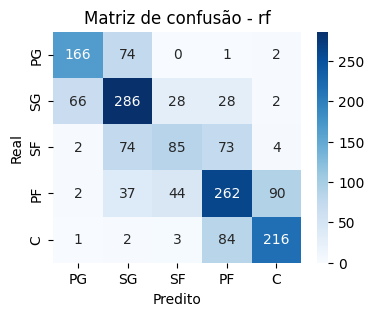

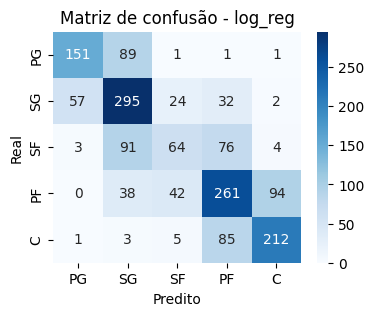

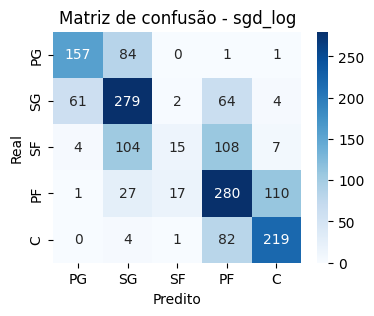

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

labels = ["PG", "SG", "SF", "PF", "C"]
for nome, model in final_models.items():
    y_pred_test = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred_test, labels=labels)

    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
                xticklabels=labels, yticklabels=labels)
    plt.title(f"Matriz de confusão - {nome}")
    plt.xlabel("Predito")
    plt.ylabel("Real")
    plt.show()


## 9. IMPORTÂNCIAS DAS FEATURES - RANDOM FOREST

In [ ]:

rf_model = best_rf.named_steps["model"]          # RandomForestClassifier dentro do pipeline
importancias = rf_model.feature_importances_

import pandas as pd

feature_importance = pd.DataFrame({
    "feature": numeric_features,
    "importance": importancias
}).sort_values("importance", ascending=False)

feature_importance.head(15)


,feature,importance
22,avgAssists,0.077653
11,avgRebounds,0.064114
34,avgBlocks,0.058988
17,avgThreePointFieldGoalsAttempted,0.053505
31,assists,0.053438
9,rebounds,0.042806
16,avgThreePointFieldGoalsMade,0.041694
36,blocks,0.039912
28,threePointFieldGoalsAttempted,0.035448
27,threePointFieldGoalsMade,0.030079


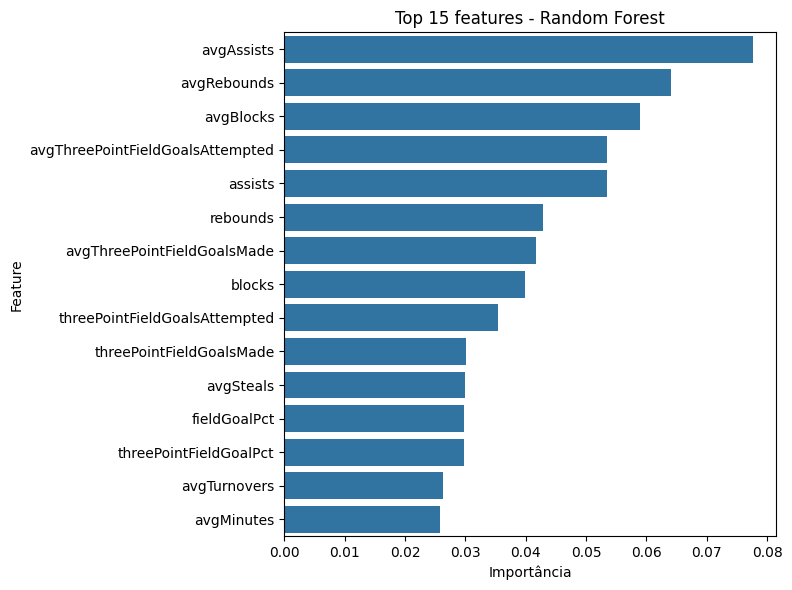

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

top_n = 15
fi_top = feature_importance.head(top_n)

plt.figure(figsize=(8, 6))
sns.barplot(data=fi_top, x="importance", y="feature")
plt.title("Top {} features - Random Forest".format(top_n))
plt.xlabel("Importância")
plt.ylabel("Feature")
plt.tight_layout()
plt.show()


## 10. CONCLUSÃO

Random Forest atinge 62.2% accuracy na classificação de posições NBA,
superando lineare. (teste final)

Fluxo completo: CV→seleção→tuning→teste final


              precision    recall  f1-score   support

           C       0.69      0.71      0.70       306
          PF       0.58      0.60      0.59       435
          PG       0.70      0.68      0.69       243
          SF       0.53      0.36      0.43       238
          SG       0.60      0.70      0.65       410

    accuracy                           0.62      1632
   macro avg       0.62      0.61      0.61      1632
weighted avg       0.62      0.62      0.62      1632



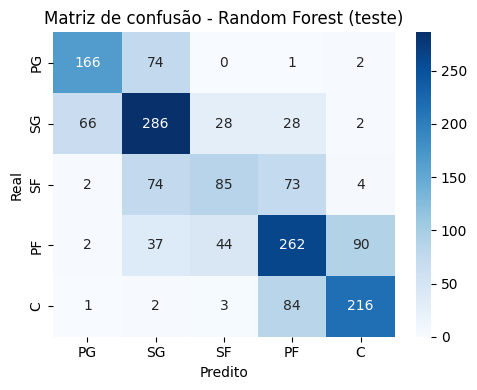

In [ ]:
from sklearn.metrics import confusion_matrix, classification_report

# predições no teste com o RF tunado
y_pred_rf = best_rf.predict(X_test)

print(classification_report(y_test, y_pred_rf))

labels = ["PG", "SG", "SF", "PF", "C"]
cm = confusion_matrix(y_test, y_pred_rf, labels=labels)

plt.figure(figsize=(5, 4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.title("Matriz de confusão - Random Forest (teste)")
plt.xlabel("Predito")
plt.ylabel("Real")
plt.tight_layout()
plt.show()
